<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/RF_Hancock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (332, 25)

Class Distribution
HPV
0    191
1    141
Name: count, dtype: int64

Training Patients: 265
Test Patients: 67

Number of Features: 25

Classification Report

              precision    recall  f1-score   support

           0     0.7955    0.8974    0.8434        39
           1     0.8261    0.6786    0.7451        28

    accuracy                         0.8060        67
   macro avg     0.8108    0.7880    0.7942        67
weighted avg     0.8083    0.8060    0.8023        67

Confusion Matrix
[[35  4]
 [ 9 19]]

Accuracy:            0.8060
Balanced Accuracy:   0.7880
F1-score:            0.7451
AUC:                 0.8613

RANDOM FOREST42_HANCOCK SUMMARY
Model : Random Forest
Input Features : 25
Learning Rate : N/A
Optimiser : N/A
Class Weights : Automatic (np.bincount)
SMOTE : No
Training Patients : 265
n_estimators : 100
Trainin

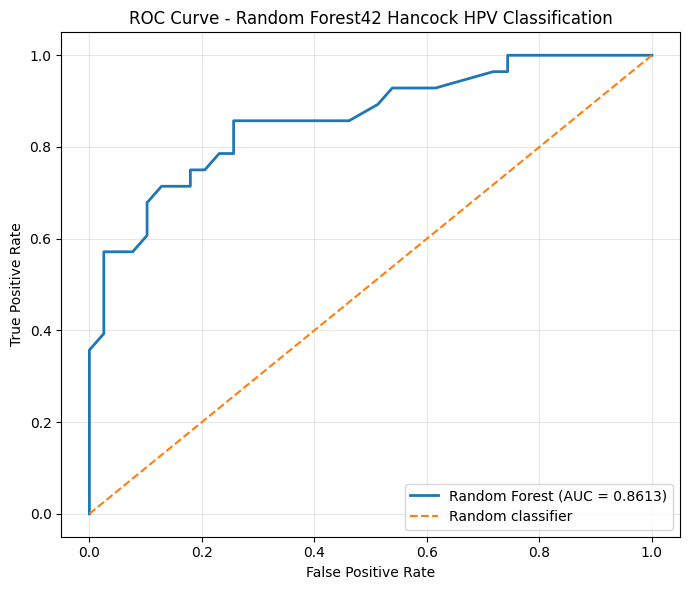

ROC AUC: 0.8613

Analysis Complete.


In [2]:
# ============================================================
# RF42_Hancock
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os,json,random,numpy as np,pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED=42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"]=str(SEED)

# ------------------------------------------------------------
# Read Data
# ------------------------------------------------------------

with open('/content/drive/MyDrive/clinical_data.json') as f:
    clinical=pd.DataFrame(json.load(f))
with open('/content/drive/MyDrive/pathological_data.json') as f:
    pathology=pd.DataFrame(json.load(f))
df=clinical.merge(pathology,on='patient_id',how='inner')

# ------------------------------------------------------------
# HPV Labels
# ------------------------------------------------------------

df=df[df['hpv_association_p16'].isin(['positive','negative'])].copy()
df['HPV']=df['hpv_association_p16'].map({'negative':0,'positive':1})

# ------------------------------------------------------------
# Build Modelling Dataset
# ------------------------------------------------------------

df_model=df[['age_at_initial_diagnosis','sex','smoking_status','primarily_metastasis','first_treatment_intent','first_treatment_modality','days_to_first_treatment','adjuvant_treatment_intent','adjuvant_radiotherapy','adjuvant_radiotherapy_modality','adjuvant_systemic_therapy','adjuvant_systemic_therapy_modality','adjuvant_radiochemotherapy','primary_tumor_site','pT_stage','pN_stage','histologic_type','number_of_positive_lymph_nodes','number_of_resected_lymph_nodes','perinodal_invasion','lymphovascular_invasion_L','vascular_invasion_V','perineural_invasion_Pn','resection_status','infiltration_depth_in_mm','HPV']].copy()

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

cat_cols=['sex','smoking_status','primarily_metastasis','first_treatment_intent','first_treatment_modality','adjuvant_treatment_intent','adjuvant_radiotherapy','adjuvant_radiotherapy_modality','adjuvant_systemic_therapy','adjuvant_systemic_therapy_modality','adjuvant_radiochemotherapy','primary_tumor_site','pT_stage','pN_stage','histologic_type','perinodal_invasion','lymphovascular_invasion_L','vascular_invasion_V','perineural_invasion_Pn','resection_status']
for col in cat_cols:
    df_model[col]=df_model[col].fillna(df_model[col].mode()[0])

num_cols=['age_at_initial_diagnosis','days_to_first_treatment','number_of_positive_lymph_nodes','number_of_resected_lymph_nodes','infiltration_depth_in_mm']
for col in num_cols:
    df_model[col]=df_model[col].fillna(df_model[col].median())

# ------------------------------------------------------------
# Label Encoding
# ------------------------------------------------------------

for col in cat_cols:
    df_model[col]=LabelEncoder().fit_transform(df_model[col].astype(str))

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

X=df_model.drop(columns=['HPV'])
y=df_model['HPV']
print("Dataset Shape:",X.shape)
print("\nClass Distribution")
print(y.value_counts())

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=SEED,stratify=y)
print("\nTraining Patients:",len(y_train))
print("Test Patients:",len(y_test))

# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
n_features=X.shape[1]
print("\nNumber of Features:",n_features)

# ============================================================
# RANDOM FOREST42_HANCOCK
# Same RF as RF42_Hecktor
# No SMOTE
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Model
# ============================================================

class_counts=np.bincount(y_train)
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weight_dict={i:class_weights[i] for i in range(len(class_weights))}

model=RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=SEED
)
model.fit(X_train,y_train)

# ============================================================
# Predictions
# ============================================================

predicted=model.predict(X_test)
probabilities=model.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report,confusion_matrix,balanced_accuracy_score,roc_auc_score,f1_score

# ============================================================
# Classification Report
# ============================================================

print()
print("Classification Report\n")
print(classification_report(y_test,predicted,digits=4))

# ============================================================
# Confusion Matrix
# ============================================================

cm=confusion_matrix(y_test,predicted)
print("Confusion Matrix")
print(cm)

# ============================================================
# Metrics
# ============================================================

accuracy=(predicted==y_test).sum()/len(y_test)
bal_acc=balanced_accuracy_score(y_test,predicted)
f1=f1_score(y_test,predicted)
auc=roc_auc_score(y_test,probabilities)

print()
print(f"Accuracy:            {accuracy:.4f}")
print(f"Balanced Accuracy:   {bal_acc:.4f}")
print(f"F1-score:            {f1:.4f}")
print(f"AUC:                 {auc:.4f}")

# ============================================================
# MODEL SUMMARY
# ============================================================

print()
print("====================================")
print("RANDOM FOREST42_HANCOCK SUMMARY")
print("====================================")
print("Model : Random Forest")
print("Input Features :",n_features)
print("Learning Rate : N/A")
print("Optimiser : N/A")
print("Class Weights : Automatic (np.bincount)")
print("SMOTE : No")
print("Training Patients :",len(y_train))
print("n_estimators :",100)
print("Training Patients :",len(y_train))
print("Test Patients :",len(y_test))
print("Seed :",SEED)
print()
print("Final Results")
print("---------------------------")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Balanced Accuracy   : {bal_acc:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"AUC                 : {auc:.4f}")
print()
print("Confusion Matrix")
print(cm)

# ============================================================
# ROC / AUC CURVE
# ============================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr,thresholds=roc_curve(y_test,probabilities)
auc_curve=roc_auc_score(y_test,probabilities)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,linewidth=2,label=f'Random Forest (AUC = {auc_curve:.4f})')
plt.plot([0,1],[0,1],linestyle='--',linewidth=1.5,label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest42 Hancock HPV Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {auc_curve:.4f}")
print()
print("Analysis Complete.")